In [1]:
import yfinance as yf
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

In [35]:
stock = yf.Ticker('FICO')
# stock = yf.Ticker('WIX')
# stock = yf.Ticker('NVDA')

In [3]:
def financial_statements(ticker):
    income_yearly = ticker.get_income_stmt()
    income_yearly = income_yearly.transpose()
    income_quarterly = ticker.get_income_stmt(freq='quarterly')
    income_quarterly = income_quarterly.transpose()
    balance_yearly = ticker.get_balance_sheet()
    balance_yearly = balance_yearly.transpose()
    balance_quarterly = ticker.get_balance_sheet(freq='quarterly')
    balance_quarterly = balance_quarterly.transpose()
    cashflow_yearly = ticker.get_cash_flow()
    cashflow_yearly = cashflow_yearly.transpose()
    cashflow_quarterly = ticker.get_cash_flow(freq='quarterly')
    cashflow_quarterly = cashflow_quarterly.transpose()
    return income_yearly, income_quarterly, balance_yearly, balance_quarterly, cashflow_yearly, cashflow_quarterly
income_y, income_q, balance_y, balance_q, cashflow_y, cashflow_q = financial_statements(ticker=stock)

In [4]:
def useful_variables(year_data, quarter_data):
    years = year_data.index.tolist()
    years = [d.strftime('%Y-%m-%d') for d in years]
    quarters = quarter_data.index.to_period('Q').astype(str)
    return years, quarters
years, quarters = useful_variables(income_y, income_q)

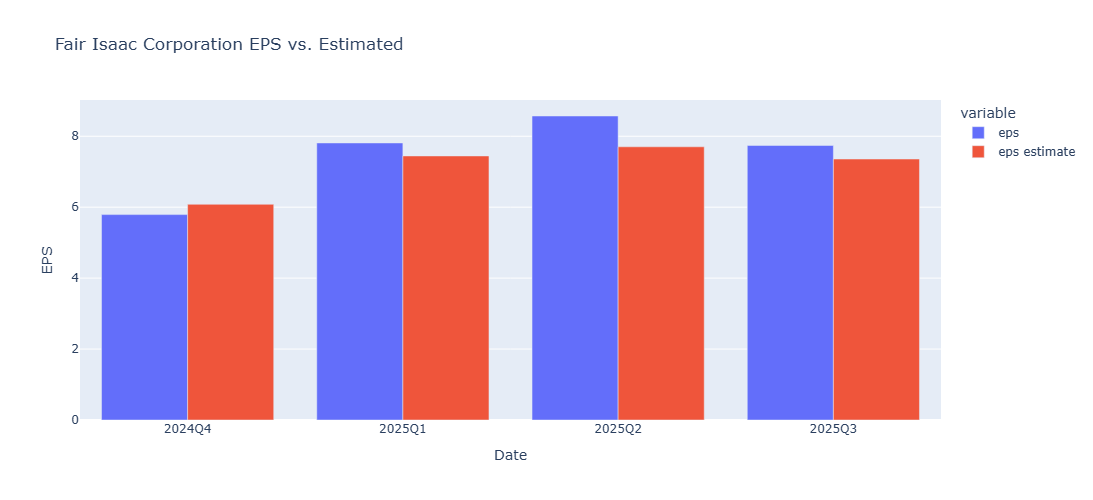

In [5]:
def actual_vs_estimate(ticker):
    historic = ticker.get_earnings_history()
    df_historic = pd.DataFrame(historic)
    # Convert to quarters for a cleaner looking xaxis
    df_historic.index = df_historic.index.to_period('Q').astype(str)
    df_historic = df_historic.reset_index()
    df_historic = df_historic.rename(columns={'epsActual': 'eps', 'epsEstimate': 'eps estimate'})
    historic_bar = px.bar(df_historic, x='quarter', y=['eps', 'eps estimate'],
                          title=f'{ticker.info['shortName']} EPS vs. Estimated', barmode='group', height=500)
    historic_bar.update_layout(xaxis_title='Date', yaxis_title='EPS')
    
    return df_historic, historic_bar
history, chart = actual_vs_estimate(ticker=stock)
chart

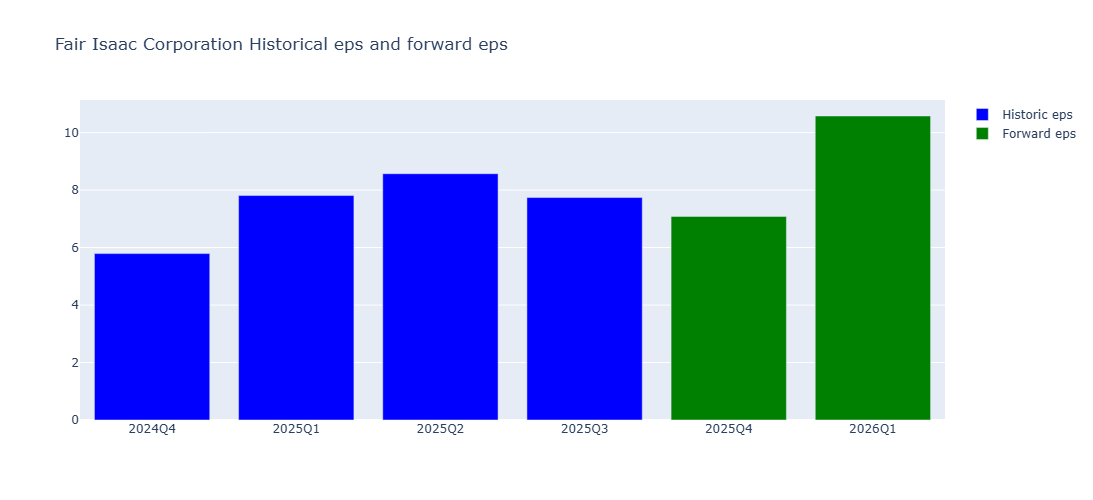

In [40]:
def future_eps(ticker, eps_previous):
    # Obtain only previous eps data from history dataframe
    eps_previous = eps_previous[['quarter', 'eps']]  
    # Obtain eps estimates for the next 2 quarters
    estimates = stock.get_earnings_estimate()
    estimates = estimates.reset_index()
    estimates = estimates.rename(columns={'period': 'quarter', 'avg': 'eps'})
    eps_estimate = estimates[['quarter', 'eps']]
    # Drop eps year data
    eps_estimate = eps_estimate.drop([2, 3])
    # Clean up eps_estimate column data
    eps_estimate.loc[0, 'quarter'] = '2025Q4'
    eps_estimate.loc[1, 'quarter'] = '2026Q1'
    # Combine historical and estimates
    # eps_combined = pd.concat([eps, eps_estimate], ignore_index=True)

    # Plot data
    eps_bar = go.Figure()
    eps_bar.add_trace(go.Bar(x=eps_previous.quarter, y=eps_previous.eps,
                             marker_color='blue', name='Historic eps'))
    eps_bar.add_trace(go.Bar(x=eps_estimate.quarter, y=eps_estimate.eps,
                             marker_color='green', name='Forward eps'))
    eps_bar.update_layout(title_text=f'{ticker.info['shortName']} Historical eps and forward eps', 
                         height=500)
    
    return eps_bar
future_eps(ticker=stock, eps_previous=history)

In [17]:
# Transpose the axes and rename the columns
trends_flip = trends.transpose()
trends_flip = trends_flip.rename(columns={'0q': 'Current Quarter', 
                                          '+1q': 'Next Quarter', 
                                          '0y': 'Current Year',
                                          '+1y': 'Next Year',}).reset_index(names='period')
trends_flip.period

0      current
1     7daysAgo
2    30daysAgo
3    60daysAgo
4    90daysAgo
Name: period, dtype: object

In [18]:
quarter_trends = trends_flip[['period', 'Current Quarter', 'Next Quarter']]

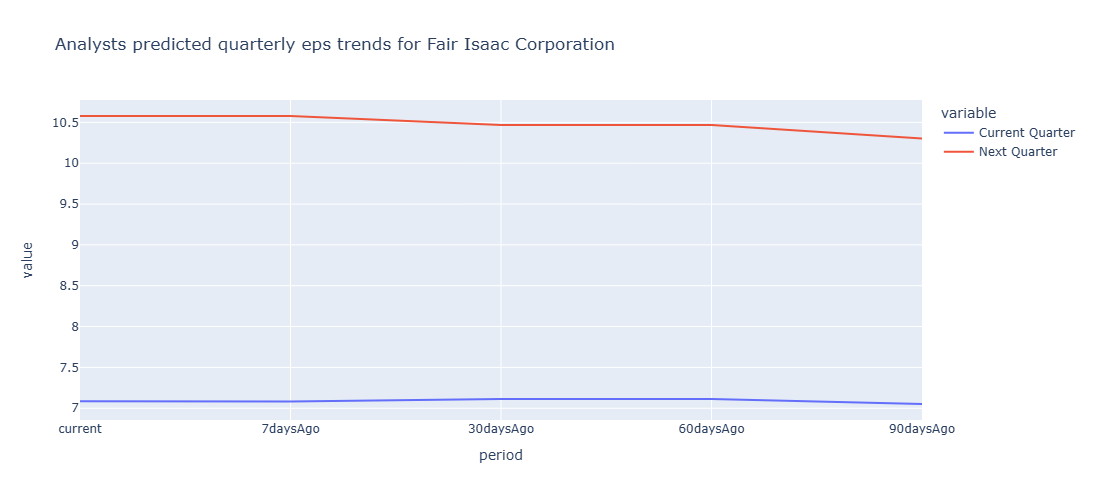

In [26]:
def get_eps_trends(ticker):
    trends = ticker.get_eps_trend()
    trends_tran = trends.transpose()
    trends_tran = trends_tran.rename(columns={'0q': 'Current Quarter', 
                                          '+1q': 'Next Quarter', 
                                          '0y': 'Current Year',
                                          '+1y': 'Next Year',}).reset_index(names='period')
    quarter_trend = trends_tran[['period', 'Current Quarter', 'Next Quarter']]
    yearly_trend = trends_tran[['period', 'Current Year', 'Next Year']]

    quarter_line = px.line(quarter_trend, x='period', y=['Current Quarter', 'Next Quarter'], 
                           height=500, title=f'Analysts predicted quarterly eps trends for {ticker.info['shortName']}')

    year_line = px.line(yearly_trend, x='period', y=['Current Year', 'Next Year'],
                        height=500, title=f'Analysts predicted yearly eps trends for {ticker.info['shortName']}')

    return quarter_line, year_line
quarter_trend_chart, year_trend_chart = get_eps_trends(ticker=stock)
quarter_trend_chart

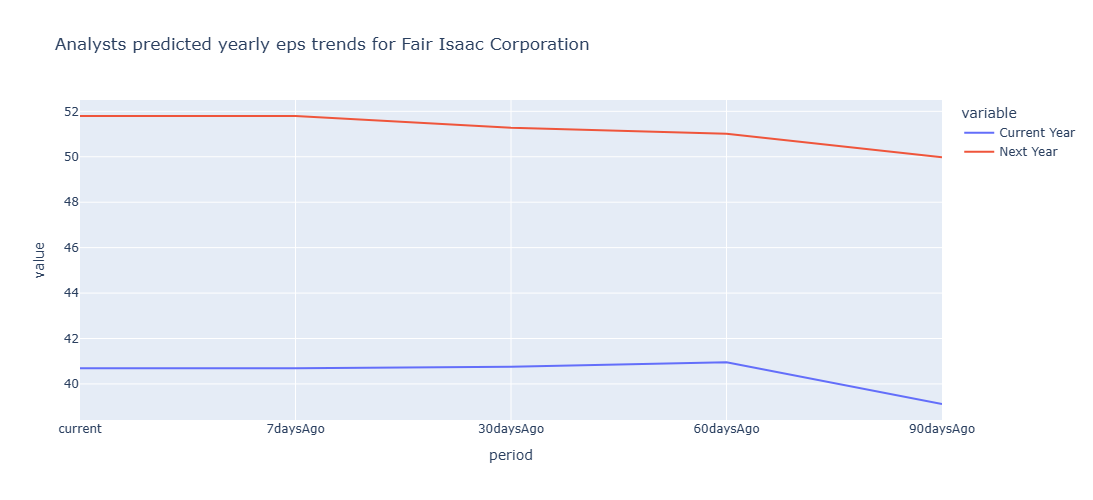

In [27]:
year_trend_chart

In [37]:
eps = stock.get_earnings_history()
eps

,epsActual,epsEstimate,epsDifference,surprisePercent
quarter,,,,
2024-12-31,5.79,6.08040,-0.29,-0.0478
2025-03-31,7.81,7.44356,0.37,0.0492
2025-06-30,8.57,7.70158,0.87,0.1128
2025-09-30,7.74,7.35683,0.38,0.0521


In [42]:
info = stock.info
info

{'address1': '5 West Mendenhall',
 'address2': 'Suite 105',
 'city': 'Bozeman',
 'state': 'MT',
 'zip': '59715',
 'country': 'United States',
 'phone': '(406) 982-7276',
 'website': 'https://www.fico.com',
 'industry': 'Software - Application',
 'industryKey': 'software-application',
 'industryDisp': 'Software - Application',
 'sector': 'Technology',
 'sectorKey': 'technology',
 'sectorDisp': 'Technology',
 'longBusinessSummary': 'Fair Isaac Corporation provides analytics software in the Americas, Europe, the Middle East, Africa, and the Asia Pacific. It operates through two segments, Scores and Software. The Scores segment offers business-to-business scoring solutions and services that give clients access to predictive credit and other scores that can be integrated into their transaction streams and decision-making processes, as well as business-to-consumer scoring solutions comprising myFICO.com subscription offerings. Its Software segment provides pre-configured analytic and decisio

In [53]:
trailing_eps = info['trailingEps']
eps_trailing_12_months = info['epsTrailingTwelveMonths']
epsCurrentYear = info['epsCurrentYear']
forward_eps = info['forwardEps']
trailing_PE = info['trailingPE']
forward_PE = info['forwardPE']

In [54]:
print(f'Trailing EPS: {trailing_eps}')
print(f'Trailing 12 month eps: {eps_trailing_12_months}')
print(f'Current year predicted eps: {epsCurrentYear}')
print(f'Foward eps: {forward_eps}')
print(f"Trailing PE: {trailing_PE}")
print(f'Forward PE: {forward_PE}')

Trailing EPS: 26.52
Trailing 12 month eps: 26.52
Current year predicted eps: 40.69518
Foward eps: 51.79481
Trailing PE: 57.405544
Forward PE: 29.392809
